# Hybrid Model Training on Synthetic Particle Data

Trains the hybrid CNN (image + scalar features, gated fusion) from the ablation study
on synthetic 2D-S particle data.

**Pipeline:**
1. Load synthetic particle metadata and image paths
2. Apply the pre-trained CNN donut filter to remove out-of-focus artifacts
   (donuts appear in synthetic data from simulated out-of-focus particles;
    they carry liquid/ice labels from their source file, introducing label noise)
3. Train/val/test split on the cleaned dataset
4. Train the hybrid model (image CNN branch + scalar feature branch, gated fusion)
5. Evaluate and save

**Classes:** 0 = Liquid, 1 = Ice

**Prerequisites:**
- Run `synthetic_preprocessing.py` → produces `synthetic_particle_images_filtered/` and `synthetic_particle_metadata.csv`
- Run `donut_filter_training.ipynb` → produces `donut_filter_results/donut_filter_model.keras`

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import pickle
from pathlib import Path
from typing import Tuple

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    SpatialDropout2D, GlobalAveragePooling2D,
    Flatten, Dense, Dropout, Concatenate, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow {tf.__version__}")
print(f"NumPy      {np.__version__}")

TensorFlow 2.20.0
NumPy      2.0.2


## 2. Configuration

In [2]:
# ── Google Colab setup ────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/GEOG5100/aircraft_ml/'
    IN_COLAB = True
except ImportError:
    base_path = './'
    IN_COLAB = False

print(f"{'Colab' if IN_COLAB else 'Local'} mode  |  base_path = {base_path}")

Mounted at /content/drive
Colab mode  |  base_path = /content/drive/MyDrive/GEOG5100/aircraft_ml/


In [6]:
# ── Paths ─────────────────────────────────────────────────────────────────────
IMAGE_BASE        = Path(base_path) / 'Data/synthetic_particle_images_filtered'
METADATA_CSV      = Path(base_path) / 'synthetic_particle_metadata.csv'
DONUT_MODEL_PATH  = Path(base_path) / 'donut_filter_results' / 'donut_filter_model.keras'
SAVE_DIR          = Path(base_path) / 'hybrid_synthetic_results'
SAVE_DIR.mkdir(exist_ok=True)

# ── Donut filter ──────────────────────────────────────────────────────────────
# Particles with P(donut) >= DONUT_THRESHOLD are removed before training.
# Increase to be more conservative (fewer false removals).
DONUT_THRESHOLD   = 0.5

# ── Features ──────────────────────────────────────────────────────────────────
# Must match feature_columns used in the ablation study.
feature_columns   = ['arearatio', 'aspectratio']

# ── Class labels ──────────────────────────────────────────────────────────────
PHASE_DIRS        = {0: 'liquid', 1: 'ice'}
CLASS_NAMES       = ['Liquid', 'Ice']
NUM_CLASSES       = 2

# ── Training hyperparameters ──────────────────────────────────────────────────
RANDOM_SEED       = 42
IMAGE_SIZE        = (128, 128)
BATCH_SIZE        = 32
EPOCHS            = 60
LEARNING_RATE     = 1e-4
L2_REG            = 1e-4
AUGMENTATION_PROB = 0.5

# ── Reproducibility ───────────────────────────────────────────────────────────
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"Saving outputs to: {SAVE_DIR}")
print(f"Donut threshold  : {DONUT_THRESHOLD}")
print(f"Features         : {feature_columns}")

Saving outputs to: /content/drive/MyDrive/GEOG5100/aircraft_ml/hybrid_synthetic_results
Donut threshold  : 0.5
Features         : ['arearatio', 'aspectratio']


In [5]:
!unzip /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered.zip -d /content/drive/MyDrive/GEOG5100/aircraft_ml/Data

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_31630.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_28361.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_27052.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_17191.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_23234.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_25645.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_particle_images_filtered/liquid/particle_32339.png  
  inflating: /content/drive/MyDrive/GEOG5100/aircraft_ml/Data/synthetic_pa

## 3. Load Synthetic Metadata

In [7]:
df = pd.read_csv(METADATA_CSV)
print(f"Total rows in metadata CSV: {len(df):,}")
print(f"\nPhase distribution (raw):")
print(df['phase'].value_counts().sort_index())
print(f"  0 = Liquid, 1 = Ice")

# Build image paths using global_particle_id
def make_image_path(row):
    subdir = PHASE_DIRS[row['phase']]
    return str(IMAGE_BASE / subdir / f"particle_{row['global_particle_id']}.png")

df['image_path'] = df.apply(make_image_path, axis=1)

# Keep only rows where the image exists on disk
exists = df['image_path'].apply(os.path.exists)
n_missing = (~exists).sum()
df = df[exists].reset_index(drop=True)
print(f"\nImages found on disk : {len(df):,}  (dropped {n_missing} missing)")
print(f"\nPhase distribution (images present):")
print(df['phase'].value_counts().sort_index())

Total rows in metadata CSV: 40,063

Phase distribution (raw):
phase
0    17303
1    22760
Name: count, dtype: int64
  0 = Liquid, 1 = Ice

Images found on disk : 39,818  (dropped 245 missing)

Phase distribution (images present):
phase
0    17220
1    22598
Name: count, dtype: int64


## 4. Apply Donut Filter (Pre-Training)

Synthetic particles can be out-of-focus in simulation, producing donut-shaped ring
artifacts. These carry liquid or ice labels from their source file, which would
introduce label noise into training. The pre-trained CNN donut filter removes them
before any splits are made.

Particles with `P(donut) >= DONUT_THRESHOLD` are excluded from the dataset.

In [8]:
assert DONUT_MODEL_PATH.exists(), (
    f"Donut filter model not found: {DONUT_MODEL_PATH}\n"
    "Run donut_filter_training.ipynb first."
)

print("Loading donut filter model ...")
donut_model = tf.keras.models.load_model(DONUT_MODEL_PATH)
print(f"  Loaded: {DONUT_MODEL_PATH.name}")

Loading donut filter model ...
  Loaded: donut_filter_model.keras


In [9]:
def load_image_for_filter(path):
    """Load a single image for donut filter inference (no label needed)."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMAGE_SIZE)
    return tf.clip_by_value(img, 0.0, 1.0)


image_paths = df['image_path'].values.astype(str)

filter_ds = (
    tf.data.Dataset.from_tensor_slices(image_paths)
    .map(load_image_for_filter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Running donut filter on {len(df):,} particles ...")
donut_probs = donut_model.predict(filter_ds, verbose=1).ravel()

df['donut_prob'] = donut_probs
is_donut = donut_probs >= DONUT_THRESHOLD

print(f"\nDonut filter results (threshold = {DONUT_THRESHOLD}):")
print(f"  Total particles : {len(df):,}")
print(f"  Flagged as donut: {is_donut.sum():,} ({is_donut.mean()*100:.1f}%)")
print(f"\nFlagged by source class:")
for phase, name in PHASE_DIRS.items():
    phase_mask = df['phase'] == phase
    n_flagged = (is_donut & phase_mask).sum()
    n_total = phase_mask.sum()
    print(f"  {name:8s} (phase {phase}): {n_flagged:,} / {n_total:,} flagged ({n_flagged/n_total*100:.1f}%)")

Running donut filter on 39,818 particles ...
623/623 ━━━━━━━━━━━━━━━━━━━━ 75s 116ms/step

Donut filter results (threshold = 0.5):
  Total particles : 39,818
  Flagged as donut: 5,595 (14.1%)

Flagged by source class:
  liquid   (phase 0): 4,198 / 17,220 flagged (24.4%)
  ice      (phase 1): 1,397 / 22,598 flagged (6.2%)


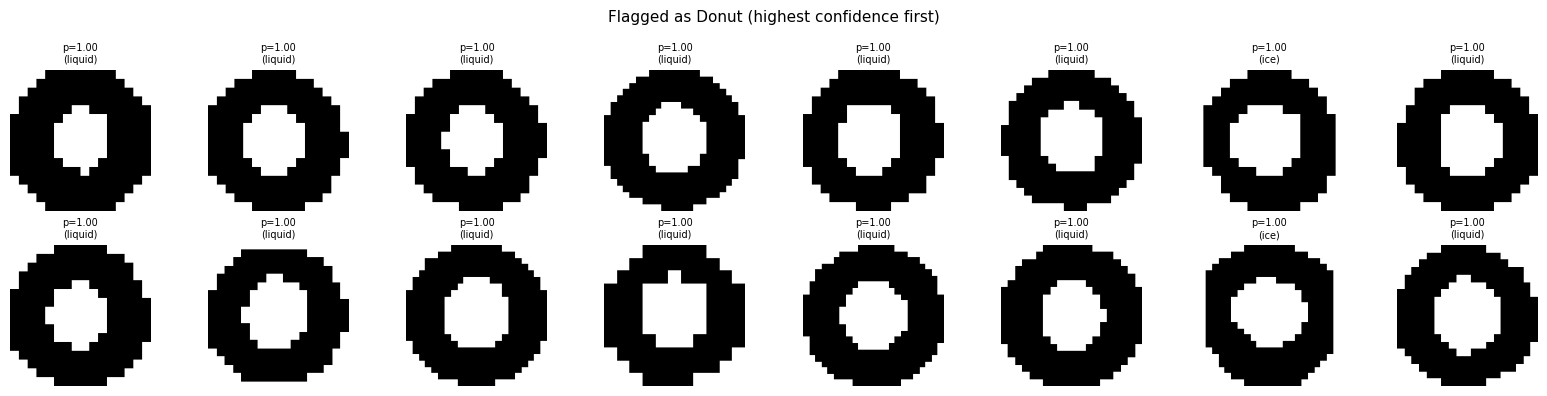

Saved → flagged_donuts.png


In [10]:
# ── Visualize flagged particles ───────────────────────────────────────────────
# Sort by highest donut probability to inspect the most confident flags first.
flagged_idx = np.where(is_donut)[0]

if len(flagged_idx) == 0:
    print("No particles flagged as donut.")
else:
    flagged_idx_sorted = flagged_idx[np.argsort(donut_probs[flagged_idx])[::-1]]
    n_show = min(16, len(flagged_idx_sorted))
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        if i < n_show:
            idx = flagged_idx_sorted[i]
            img_raw = tf.image.decode_png(
                tf.io.read_file(df['image_path'].iloc[idx]), channels=1
            ).numpy()[:, :, 0]
            phase_name = PHASE_DIRS[df['phase'].iloc[idx]]
            ax.imshow(img_raw, cmap='gray')
            ax.set_title(f"p={donut_probs[idx]:.2f}\n({phase_name})", fontsize=7)
        ax.axis('off')
    plt.suptitle('Flagged as Donut (highest confidence first)', fontsize=11)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'flagged_donuts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → flagged_donuts.png")

In [11]:
# ── Remove flagged particles ───────────────────────────────────────────────────
n_before = len(df)
df_clean = df[~is_donut].reset_index(drop=True)
n_after  = len(df_clean)

print(f"Before donut filter : {n_before:,}")
print(f"After  donut filter : {n_after:,}  (removed {n_before - n_after:,})")
print(f"\nClass distribution after filtering:")
print(df_clean['phase'].value_counts().sort_index())

Before donut filter : 39,818
After  donut filter : 34,223  (removed 5,595)

Class distribution after filtering:
phase
0    13022
1    21201
Name: count, dtype: int64


## 5. Feature Preparation

Extract scalar features and handle any missing values before splitting.

In [12]:
# Fill NaN with column mean
for col in feature_columns:
    n_nan = df_clean[col].isna().sum()
    if n_nan > 0:
        mean_val = df_clean[col].mean()
        df_clean[col] = df_clean[col].fillna(mean_val)
        print(f"  {col}: filled {n_nan} NaN values with mean={mean_val:.4f}")

X_features = df_clean[feature_columns].values.astype(np.float32)
X_paths    = df_clean['image_path'].values.astype(str)
y_labels   = df_clean['phase'].values.astype(int)

print(f"Feature matrix shape : {X_features.shape}")
print(f"Features             : {feature_columns}")
print(f"Labels shape         : {y_labels.shape}")
print(f"\nFeature statistics:")
print(pd.DataFrame(X_features, columns=feature_columns).describe())

Feature matrix shape : (34223, 2)
Features             : ['arearatio', 'aspectratio']
Labels shape         : (34223,)

Feature statistics:
          arearatio   aspectratio
count  34223.000000  34223.000000
mean       0.612647      0.629287
std        0.229433      0.240779
min        0.012921      0.043478
25%        0.434312      0.449572
50%        0.538242      0.605337
75%        0.860973      0.835084
max        1.000000      1.000000


## 6. Train / Val / Test Split

In [13]:
# 80 / 10 / 10 stratified split
paths_temp, paths_test, feat_temp, feat_test, y_temp, y_test = train_test_split(
    X_paths, X_features, y_labels,
    test_size=0.10, stratify=y_labels, random_state=RANDOM_SEED
)
paths_train, paths_val, feat_train, feat_val, y_train, y_val = train_test_split(
    paths_temp, feat_temp, y_temp,
    test_size=0.111, stratify=y_temp, random_state=RANDOM_SEED
)

print(f"Train : {len(paths_train):,}")
print(f"Val   : {len(paths_val):,}")
print(f"Test  : {len(paths_test):,}")

for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = {name: (y_split == i).sum() for i, name in enumerate(CLASS_NAMES)}
    print(f"  {split_name}: " + ", ".join(f"{k}={v}" for k, v in counts.items()))

# Class weights (computed on training set only)
weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(weights)}
print(f"\nClass weights: {class_weight_dict}")

Train : 27,381
Val   : 3,419
Test  : 3,423
  Train: Liquid=10419, Ice=16962
  Val: Liquid=1301, Ice=2118
  Test: Liquid=1302, Ice=2121

Class weights: {0: np.float64(1.3139936654189461), 1: np.float64(0.8071276972055182)}


## 7. Feature Scaling

Fit scaler on training set only, then transform all splits.

In [14]:
scaler = StandardScaler()
feat_train_scaled = scaler.fit_transform(feat_train).astype(np.float32)
feat_val_scaled   = scaler.transform(feat_val).astype(np.float32)
feat_test_scaled  = scaler.transform(feat_test).astype(np.float32)

print(f"Scaler mean  : {scaler.mean_}")
print(f"Scaler scale : {scaler.scale_}")

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

# Save scaler for inference
scaler_path = SAVE_DIR / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump({'scaler': scaler, 'feature_columns': feature_columns}, f)
print(f"\nScaler saved → {scaler_path}")

Scaler mean  : [0.61241988 0.62868476]
Scaler scale : [0.22936084 0.24090346]

Scaler saved → /content/drive/MyDrive/GEOG5100/aircraft_ml/hybrid_synthetic_results/scaler.pkl


## 8. tf.data Pipelines

In [15]:
def random_geometric_augment(image: tf.Tensor) -> tf.Tensor:
    """Random 90-degree rotation."""
    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k=k)
    return image


def load_and_augment_hybrid(
    image_path: str,
    feature_vector: tf.Tensor,
    label: tf.Tensor,
    augment: bool
) -> Tuple[Tuple[tf.Tensor, tf.Tensor], tf.Tensor]:
    """Load image, optionally augment, return ((image, features), label)."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    image = tf.image.resize(image, IMAGE_SIZE)

    if augment:
        if tf.random.uniform(()) < AUGMENTATION_PROB:
            image = tf.image.flip_left_right(image)
        if tf.random.uniform(()) < AUGMENTATION_PROB:
            image = tf.image.flip_up_down(image)
        if tf.random.uniform(()) < AUGMENTATION_PROB:
            image = random_geometric_augment(image)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return (image, feature_vector), label


def make_hybrid_dataset(paths, features, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, features, labels))
    ds = ds.map(
        lambda p, f, l: load_and_augment_hybrid(p, f, l, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_hybrid_dataset(paths_train, feat_train_scaled, y_train_cat, augment=True,  shuffle=True)
val_ds   = make_hybrid_dataset(paths_val,   feat_val_scaled,   y_val_cat,   augment=False, shuffle=False)
test_ds  = make_hybrid_dataset(paths_test,  feat_test_scaled,  y_test_cat,  augment=False, shuffle=False)

print("Datasets created.")

# Sanity check: one batch
for (imgs, feats), lbls in train_ds.take(1):
    print(f"  Image batch  : {imgs.shape}")
    print(f"  Feature batch: {feats.shape}")
    print(f"  Label batch  : {lbls.shape}")

Datasets created.
  Image batch  : (32, 128, 128, 1)
  Feature batch: (32, 2)
  Label batch  : (32, 2)


## 9. Model Architecture

Exact architecture from the ablation study (best-performing configuration, 37,634 parameters).

- **CNN branch**: 2-block conv (16→32 filters) + GlobalAveragePooling → Dense(32)
- **Feature branch**: Dense(128→64→32)
- **Fusion**: Concatenate → sigmoid gate (`Multiply`) → Dense(128→64) → softmax

In [16]:
def build_cnn_branch(input_shape=(128, 128, 1), L2_REG=0.0001):
    """
    Simplified 2-block CNN with GlobalAveragePooling.
    Matches the final architecture from the ablation study.
    """
    image_input = Input(shape=input_shape, name='image_input')

    x = Conv2D(16, (3, 3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(L2_REG))(image_input)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((4, 4), padding='same')(x)

    x = GlobalAveragePooling2D()(x)

    cnn_features = Dense(32, activation='relu',
                         kernel_regularizer=regularizers.l2(L2_REG),
                         name='cnn_features')(x)

    return image_input, cnn_features


def build_feature_branch(num_features=len(feature_columns), L2_REG=0.0001):
    """
    Dense branch for scalar features.
    Matches the ablation study feature branch.
    """
    feature_input = Input(shape=(num_features,), name='feature_input')

    f = Dense(128, activation='relu',
              kernel_regularizer=regularizers.l2(L2_REG))(feature_input)
    f = Dropout(0.2)(f)
    f = Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(L2_REG),
              name='feature_embeddin1')(f)
    f = Dropout(0.2)(f)
    f = Dense(32, activation='relu',
              kernel_regularizer=regularizers.l2(L2_REG),
              name='feature_embedding')(f)
    f = Dropout(0.2)(f)

    return feature_input, f


def build_gated_classification_head(concat, num_classes=2, L2_REG=0.001):
    """
    Gated fusion head from the ablation study.
    Learns a sigmoid gate over the concatenated embedding,
    then passes the gated features through Dense layers.
    """
    gate = Dense(concat.shape[-1], activation='sigmoid',
                 kernel_regularizer=regularizers.l2(L2_REG),
                 name='fusion_gate')(concat)
    gated_features = Multiply(name='gated_fusion')([concat, gate])

    z = Dense(128, activation='relu',
              kernel_regularizer=regularizers.l2(L2_REG))(gated_features)
    z = Dropout(0.2)(z)
    z = Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(L2_REG))(z)
    z = Dropout(0.2)(z)

    output = Dense(num_classes, activation='softmax', name='output')(z)
    return output


def build_hybrid_model(num_features=len(feature_columns), num_classes=NUM_CLASSES, L2_REG=0.0001):
    image_input, cnn_features     = build_cnn_branch(L2_REG=L2_REG)
    feature_input, feat_embedding = build_feature_branch(num_features, L2_REG)
    combined = Concatenate()([cnn_features, feat_embedding])
    output   = build_gated_classification_head(combined, num_classes, L2_REG)
    model    = Model(inputs=[image_input, feature_input], outputs=output, name='Hybrid_Model')
    return model


model = build_hybrid_model()
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "Hybrid_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        384 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embeddin1   │ (None, 64)        │      8,256 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ feature_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embedding   │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_features        │ (None, 32)        │      1,056 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ feature_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ cnn_features[0][… │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_gate (Dense) │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 37,634 (147.01 KB)

 Trainable params: 37,538 (146.63 KB)

 Non-trainable params: 96 (384.00 B)


Total parameters: 37,634


## 10. Train

In [17]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model_save_path = str(SAVE_DIR / 'hybrid_synthetic_model.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        model_save_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
856/856 ━━━━━━━━━━━━━━━━━━━━ 90s 83ms/step - accuracy: 0.8771 - auc: 0.9466 - loss: 0.3421 - val_accuracy: 0.9041 - val_auc: 0.9779 - val_loss: 0.2399 - learning_rate: 1.0000e-04
Epoch 2/60
856/856 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.9194 - auc: 0.9776 - loss: 0.2247 - val_accuracy: 0.9248 - val_auc: 0.9869 - val_loss: 0.1823 - learning_rate: 1.0000e-04
Epoch 3/60
856/856 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.9290 - auc: 0.9836 - loss: 0.1958 - val_accuracy: 0.9412 - val_auc: 0.9896 - val_loss: 0.1626 - learning_rate: 1.0000e-04
Epoch 4/60
856/856 ━━━━━━━━━━━━━━━━━━━━ 55s 60ms/step - accuracy: 0.9381 - auc: 0.9865 - loss: 0.1802 - val_accuracy: 0.9427 - val_auc: 0.9903 - val_loss: 0.1577 - learning_rate: 1.0000e-04
Epoch 5/60
856/856 ━━━━━━━━━━━━━━━━━━━━ 55s 60ms/step - accuracy: 0.9406 - auc: 0.9876 - loss: 0.1736 - val_accuracy: 0.9459 - val_auc: 0.9913 - val_loss: 0.1505 - learning_rate: 1.0000e-04
Epoch 6/60
856/856 ━━━━━━━━━━━━━━━━━━━━ 55s 60ms/s

## 11. Training Curves

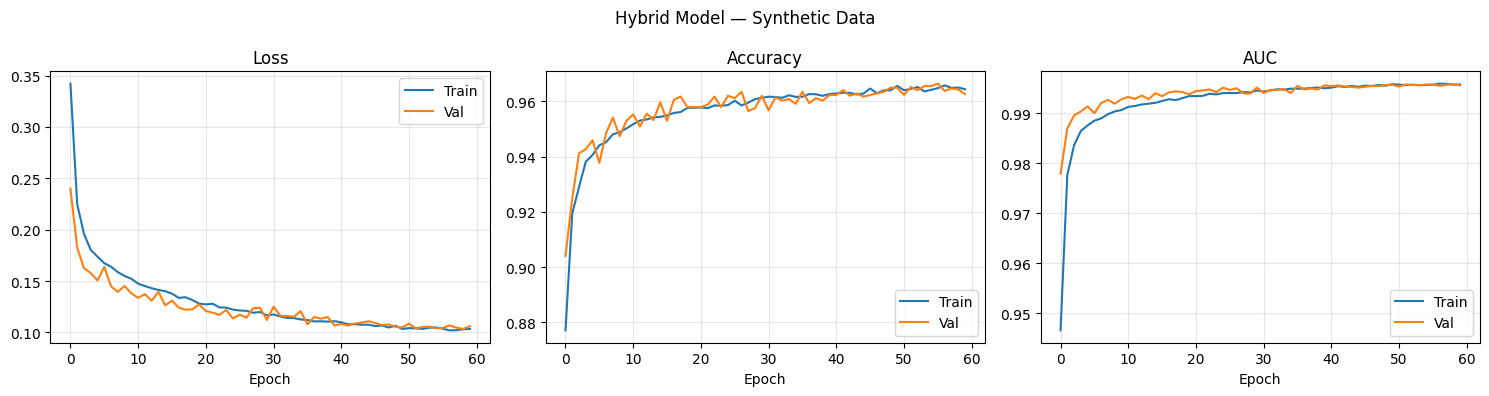

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'accuracy', 'auc'],
    ['Loss', 'Accuracy', 'AUC']
):
    ax.plot(history.history[metric],          label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Hybrid Model — Synthetic Data', fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluate on Test Set

Classification Report:
              precision    recall  f1-score   support

      Liquid       0.96      0.97      0.97      1302
         Ice       0.98      0.98      0.98      2121

    accuracy                           0.97      3423
   macro avg       0.97      0.97      0.97      3423
weighted avg       0.97      0.97      0.97      3423



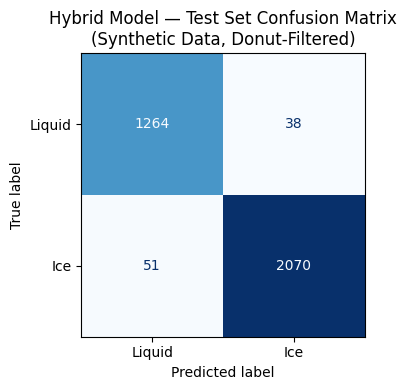

In [19]:
# Load best checkpoint
model = tf.keras.models.load_model(model_save_path)

# Predict
probs  = model.predict(test_ds, verbose=0)
y_pred = np.argmax(probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Hybrid Model — Test Set Confusion Matrix\n(Synthetic Data, Donut-Filtered)')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

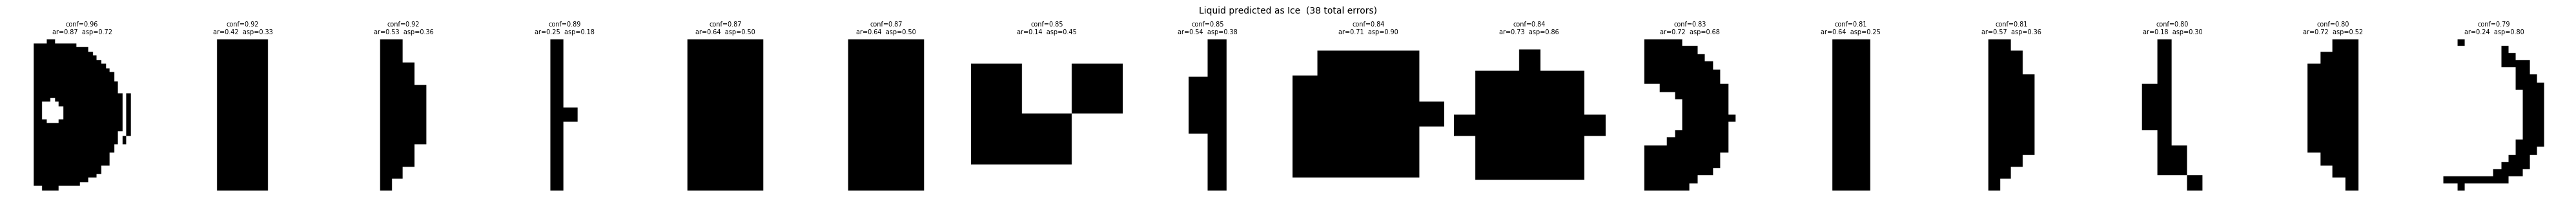

Saved → errors_liq_as_ice.png


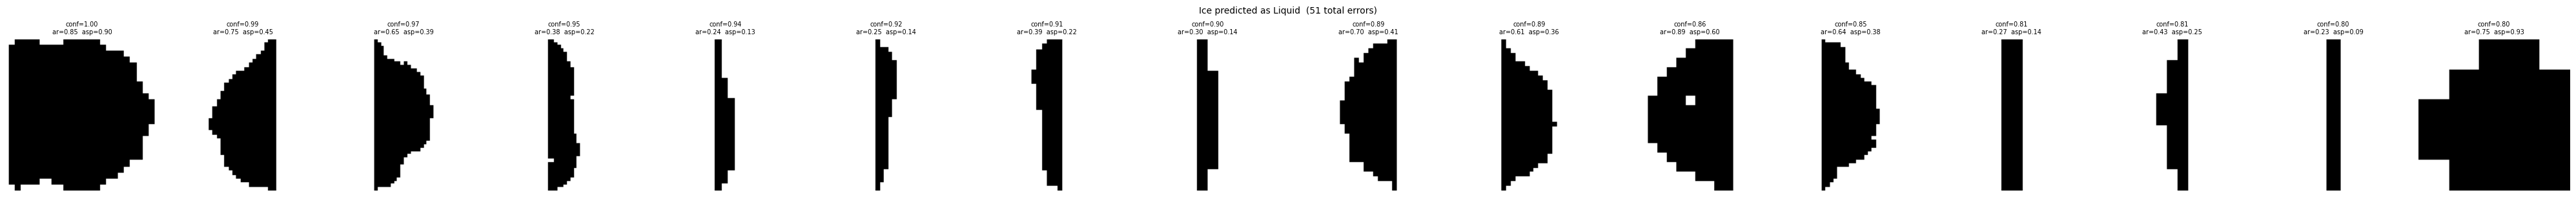

Saved → errors_ice_as_liq.png

Total misclassified: 89 / 3423 (2.6%)


In [24]:
N_SHOW = 16  # particles to display per error type

# confidence of the predicted (wrong) class
confidence = np.max(probs, axis=1)

error_types = [
    (0, 1, 'Liquid predicted as Ice',    'royalblue', 'orangered'),
    (1, 0, 'Ice predicted as Liquid',    'orangered',  'royalblue'),
]

for true_cls, pred_cls, title, true_color, pred_color in error_types:
    mask = (y_test == true_cls) & (y_pred == pred_cls)
    err_idx = np.where(mask)[0]

    if len(err_idx) == 0:
        print(f"No errors of type: {title}")
        continue

    # Sort by confidence descending (most confident wrong predictions first)
    err_idx = err_idx[np.argsort(confidence[err_idx])[::-1]]
    n = min(N_SHOW, len(err_idx))

    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3.2))
    if n == 1:
        axes = [axes]

    for col, idx in enumerate(err_idx[:n]):
        ax = axes[col]
        img_raw = tf.image.decode_png(
            tf.io.read_file(paths_test[idx]), channels=1
        ).numpy()[:, :, 0]

        ar  = feat_test[idx, feature_columns.index('arearatio')]
        asp = feat_test[idx, feature_columns.index('aspectratio')]

        ax.imshow(img_raw, cmap='gray')
        ax.set_title(
            f"conf={confidence[idx]:.2f}\n"
            f"ar={ar:.2f}  asp={asp:.2f}",
            fontsize=7
        )
        ax.set_xlabel(
            f"true={CLASS_NAMES[true_cls]}  pred={CLASS_NAMES[pred_cls]}",
            fontsize=6, color=pred_color
        )
        ax.axis('off')

    fig.suptitle(f"{title}  ({len(err_idx)} total errors)", fontsize=10)
    plt.tight_layout()
    save_name = f"errors_{'liq_as_ice' if true_cls == 0 else 'ice_as_liq'}.png"
    plt.savefig(SAVE_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_name}")

total_errors = (y_test != y_pred).sum()
print(f"\nTotal misclassified: {total_errors} / {len(y_test)} ({total_errors/len(y_test)*100:.1f}%)")

## 13. Save Outputs

In [20]:
print("Files saved to:", SAVE_DIR)
for f in sorted(SAVE_DIR.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45}  {size_kb:>8.1f} KB")

print(f"""
To use this model in particle_phase_inference.ipynb:
  MODEL_PATH       = '{model_save_path}'
  DATA_SPLITS_PATH = '{str(SAVE_DIR / 'scaler.pkl')}'
  DONUT_FILTER     = True  (recommended)
  DONUT_MODEL_PATH = '{str(DONUT_MODEL_PATH)}'
""")

Files saved to: /content/drive/MyDrive/GEOG5100/aircraft_ml/hybrid_synthetic_results
  confusion_matrix.png                               29.3 KB
  flagged_donuts.png                                 41.0 KB
  hybrid_synthetic_model.keras                      543.4 KB
  scaler.pkl                                          0.5 KB
  training_curves.png                               104.9 KB

To use this model in particle_phase_inference.ipynb:
  MODEL_PATH       = '/content/drive/MyDrive/GEOG5100/aircraft_ml/hybrid_synthetic_results/hybrid_synthetic_model.keras'
  DATA_SPLITS_PATH = '/content/drive/MyDrive/GEOG5100/aircraft_ml/hybrid_synthetic_results/scaler.pkl'
  DONUT_FILTER     = True  (recommended)
  DONUT_MODEL_PATH = '/content/drive/MyDrive/GEOG5100/aircraft_ml/donut_filter_results/donut_filter_model.keras'

